In [3]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# pycaret library

In [5]:
!pip install pycaret

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 320 kB 5.0 MB/s 
     |████████████████████████████████| 1.7 MB 64.2 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 1.3 MB 50.3 MB/s 
     |████████████████████████████████| 141 kB 75.5 MB/s 
     |████████████████████████████████| 167 kB 72.9 MB/s 
     |████████████████████████████████| 25.9 MB 1.4 MB/s 
     |████████████████████████████████| 88 kB 9.4 MB/s 
     |████████████████████████████████| 315 kB 70.6 MB/s 
     |████████████████████████████████| 2.0 MB 57.3 MB/s 
     |████████████████████████████████| 4.8 MB 45.4 MB/s 
     |████████████████████████████████| 17.0 MB 52 kB/s 
     |████████████████████████████████| 56 kB 6.4 MB/s 
     |████████████████████████████████| 63

In [6]:
import pycaret

In [4]:
from pycaret.datasets import get_data
dataset = pd.read_csv('/content/indian_liver_patient.csv')
dataset.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [8]:
dataset.shape

(583, 11)

In [9]:
dataset.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [10]:
dataset.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [5]:
# splitting the data into training and test
# training data
data = dataset.sample(frac=0.90, random_state=1).reset_index(drop=True)
# test data
data_unseen = dataset.drop(data.index).reset_index(drop=True)

In [21]:
data.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
520,45,1,1.7,0.8,315,12,38,6.3,2.1,0.5,1
521,50,1,4.2,2.3,450,69,50,7.0,3.0,0.7,1
522,50,0,1.0,0.5,239,16,39,7.5,3.7,0.9,1
523,55,1,75.0,3.6,332,40,66,6.2,2.5,0.6,1
524,45,0,0.7,0.2,153,41,42,4.5,2.2,0.9,2


In [20]:
data['Albumin_and_Globulin_Ratio'] = data['Albumin_and_Globulin_Ratio'].fillna(data['Albumin_and_Globulin_Ratio'].median())

In [22]:
data.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [23]:
data['Gender'] = data['Gender'].astype('category')
data['Gender'] = data['Gender'].cat.codes

In [24]:
x = data.iloc[:,0:-1]
y = data.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.9, random_state=1)


In [12]:
print("Data for Modeling :" + str(data.shape))
print("###########"*10)
print("Unseen Data for Prediction :" + str(data_unseen.shape))

Data for Modeling :(525, 11)
##############################################################################################################
Unseen Data for Prediction :(58, 11)


In [18]:
!pip install numba==0.53

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 3.4 MB 5.1 MB/s 
     |████████████████████████████████| 25.3 MB 85.6 MB/s 
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.37.0
    Uninstalling llvmlite-0.37.0:
      Successfully uninstalled llvmlite-0.37.0
  Attempting uninstall: numba
    Found existing installation: numba 0.54.1
    Uninstalling numba-0.54.1:
      Successfully uninstalled numba-0.54.1


In [1]:
from pycaret.classification import *

In [6]:
exp_clf101 = setup(data=data, target='Dataset' , session_id=123)

,Description,Value
0,session_id,123
1,Target,Dataset
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(525, 11)"
5,Missing Values,True
6,Numeric Features,9
7,Categorical Features,1
8,Ordinal Features,False
9,High Cardinality Features,False


INFO:logs:create_model_container: 0
INFO:logs:master_model_container: 0
INFO:logs:display_container: 1
INFO:logs:Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True, features_todrop=[],
                                      id_columns=[],
                                      ml_usecase='classification',
                                      numerical_features=[], target='Dataset',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                                fill_value_categorical=None,
                                fill_value_numerical=None,
                                numeric_stra...
                ('scaling', 'passthrough'), ('P_transform', 'passthrough'),
                ('binn', 'passthrough'), ('rem_outliers', 'passthrough'),
                ('cluste

In [7]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7603,0.7250,0.9270,0.7907,0.8525,0.2179,0.2433,0.437
rf,Random Forest Classifier,0.7526,0.7356,0.9279,0.7838,0.8488,0.1858,0.2093,0.451
dummy,Dummy Classifier,0.7493,0.5000,1.0000,0.7493,0.8567,0.0000,0.0000,0.012
ridge,Ridge Classifier,0.7411,0.0000,0.9890,0.7472,0.8511,-0.0151,-0.0235,0.010
lda,Linear Discriminant Analysis,0.7355,0.7009,0.9816,0.7457,0.8474,-0.0251,-0.0375,0.012
lightgbm,Light Gradient Boosting Machine,0.7279,0.6909,0.8767,0.7844,0.8262,0.1847,0.1989,0.098
lr,Logistic Regression,0.7247,0.7266,0.9530,0.7485,0.8376,-0.0033,-0.0015,0.357
gbc,Gradient Boosting Classifier,0.7197,0.7138,0.8589,0.7874,0.8197,0.1791,0.1836,0.087
knn,K Neighbors Classifier,0.7141,0.6369,0.8622,0.7808,0.8178,0.1449,0.1562,0.112
ada,Ada Boost Classifier,0.7137,0.6905,0.8368,0.7932,0.8134,0.1961,0.1998,0.082


INFO:logs:create_model_container: 14
INFO:logs:master_model_container: 14
INFO:logs:display_container: 2
INFO:logs:ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)
INFO:logs:compare_models() succesfully completed......................................


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)

In [ ]:
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)

In [8]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7297,0.8333,0.9643,0.7500,0.8437,-0.0511,-0.0945
1,0.6216,0.4048,0.7857,0.7333,0.7586,-0.1116,-0.1130
2,0.7297,0.7183,0.9643,0.7500,0.8437,-0.0511,-0.0945
3,0.7568,0.7540,1.0000,0.7568,0.8615,0.0000,0.0000
4,0.7838,0.7540,0.9643,0.7941,0.8710,0.2410,0.2932
5,0.7568,0.8111,1.0000,0.7500,0.8571,0.1395,0.2739
6,0.7297,0.7111,1.0000,0.7297,0.8437,0.0000,0.0000
7,0.6944,0.6872,0.9259,0.7353,0.8197,-0.1000,-0.1400
8,0.6944,0.8354,0.9259,0.7353,0.8197,-0.1000,-0.1400


INFO:logs:create_model_container: 15
INFO:logs:master_model_container: 15
INFO:logs:display_container: 3
INFO:logs:LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)
INFO:logs:create_model() succesfully completed......................................


In [9]:
et = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7838,0.6944,1.0000,0.7778,0.8750,0.1591,0.2940
1,0.7838,0.5675,0.8929,0.8333,0.8621,0.3648,0.3695
2,0.7297,0.5794,0.9643,0.7500,0.8437,-0.0511,-0.0945
3,0.7568,0.7679,0.8929,0.8065,0.8475,0.2550,0.2633
4,0.7838,0.7579,0.9643,0.7941,0.8710,0.2410,0.2932
5,0.8378,0.9370,0.9630,0.8387,0.8966,0.5297,0.5578
6,0.6216,0.6315,0.8148,0.7097,0.7586,-0.0975,-0.1026
7,0.7222,0.6626,0.8519,0.7931,0.8214,0.2000,0.2026
8,0.7500,0.8477,0.9630,0.7647,0.8525,0.1000,0.1400


INFO:logs:create_model_container: 16
INFO:logs:master_model_container: 16
INFO:logs:display_container: 4
INFO:logs:ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)
INFO:logs:create_model() succesfully completed......................................


In [25]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)



In [ ]:
x_train.head()

In [26]:
lr_model.fit(x_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [27]:
y_pred_train = lr_model.predict(x_train)
y_pred_test = lr_model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
print("Training Accuracy : ", accuracy_score(y_train, y_pred_train))
print("#########"*10)
print("Test Accuracy : ", accuracy_score(y_test, y_pred_test))

Training Accuracy :  0.7330508474576272
##########################################################################################
Test Accuracy :  0.7735849056603774


In [32]:
from sklearn.model_selection import cross_val_score
training_accuracy = cross_val_score(lr_model, x_train, y_train, cv=10)
test_accuracy = cross_val_score(lr_model, x_test, y_test, cv=10)
print(training_accuracy.mean())
print("############"*10)
print(test_accuracy.mean())

0.7290336879432624
########################################################################################################################
0.74


In [33]:
plot_model(lr, plot='auc')

INFO:logs:Initializing plot_model()
INFO:logs:plot_model(fold=None, use_train_data=False, verbose=True, is_in_evaluate=False, display=None, display_format=None, estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False), feature_name=None, fit_kwargs=None, groups=None, label=False, plot=auc, plot_kwargs=None, save=False, scale=1, system=True)
INFO:logs:Checking exceptions
INFO:logs:Preparing display monitor


IntProgress(value=0, description='Processing: ', max=5)

INFO:logs:Preloading libraries
INFO:logs:Copying training dataset
INFO:logs:Copying test dataset
INFO:logs:Plot type: auc
INFO:logs:Initializing get_config()
INFO:logs:get_config(variable=prep_pipe)
INFO:logs:Global variable: prep_pipe returned as Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True, features_todrop=[],
                                      id_columns=[],
                                      ml_usecase='classification',
                                      numerical_features=[], target='Dataset',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                                fill_value_categorical=None,
                                fill_value_numerical=None,
                                numeric_stra...
                ('scaling', 'passthroug

ValueError: ignored

<Figure size 576x396 with 0 Axes>

In [35]:
tuned_lr = tune_model(lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7297,0.8452,0.9643,0.7500,0.8437,-0.0511,-0.0945
1,0.6486,0.4484,0.8214,0.7419,0.7797,-0.0761,-0.0785
2,0.7838,0.6984,1.0000,0.7778,0.8750,0.1591,0.2940
3,0.7297,0.7540,0.9643,0.7500,0.8437,-0.0511,-0.0945
4,0.8108,0.7778,1.0000,0.8000,0.8889,0.3019,0.4216
5,0.7838,0.7815,1.0000,0.7714,0.8710,0.2673,0.3928
6,0.7297,0.6852,1.0000,0.7297,0.8437,0.0000,0.0000
7,0.7222,0.6996,0.9259,0.7576,0.8333,0.0476,0.0580
8,0.6944,0.8272,0.9259,0.7353,0.8197,-0.1000,-0.1400


INFO:logs:create_model_container: 18
INFO:logs:master_model_container: 18
INFO:logs:display_container: 6
INFO:logs:LogisticRegression(C=7.863, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)
INFO:logs:tune_model() succesfully completed......................................


In [36]:
tuned_et = tune_model(et)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7568,0.5,1.0,0.7568,0.8615,0.0,0.0
1,0.7568,0.5,1.0,0.7568,0.8615,0.0,0.0
2,0.7568,0.5,1.0,0.7568,0.8615,0.0,0.0
3,0.7568,0.5,1.0,0.7568,0.8615,0.0,0.0
4,0.7568,0.5,1.0,0.7568,0.8615,0.0,0.0
5,0.7297,0.5,1.0,0.7297,0.8437,0.0,0.0
6,0.7297,0.5,1.0,0.7297,0.8437,0.0,0.0
7,0.7500,0.5,1.0,0.7500,0.8571,0.0,0.0
8,0.7500,0.5,1.0,0.7500,0.8571,0.0,0.0


INFO:logs:create_model_container: 19
INFO:logs:master_model_container: 19
INFO:logs:display_container: 7
INFO:logs:ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight={},
                     criterion='gini', max_depth=3, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.1, min_impurity_split=None,
                     min_samples_leaf=4, min_samples_split=9,
                     min_weight_fraction_leaf=0.0, n_estimators=70, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)
INFO:logs:tune_model() succesfully completed......................................


In [37]:
plot_model(et, plot='auc')

INFO:logs:Initializing plot_model()
INFO:logs:plot_model(fold=None, use_train_data=False, verbose=True, is_in_evaluate=False, display=None, display_format=None, estimator=ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='auto',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_impurity_split=None,
                     min_samples_leaf=1, min_samples_split=2,
                     min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False), feature_name=None, fit_kwargs=None, groups=None, label=False, plot=auc, plot_kwargs=None, save=False, scale=1, system=True)
INFO:logs:Checking exceptions
INFO:logs:Preparing display monitor


IntProgress(value=0, description='Processing: ', max=5)

INFO:logs:Preloading libraries
INFO:logs:Copying training dataset
INFO:logs:Copying test dataset
INFO:logs:Plot type: auc
INFO:logs:Initializing get_config()
INFO:logs:get_config(variable=prep_pipe)
INFO:logs:Global variable: prep_pipe returned as Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True, features_todrop=[],
                                      id_columns=[],
                                      ml_usecase='classification',
                                      numerical_features=[], target='Dataset',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                                fill_value_categorical=None,
                                fill_value_numerical=None,
                                numeric_stra...
                ('scaling', 'passthroug

ValueError: ignored

<Figure size 576x396 with 0 Axes>

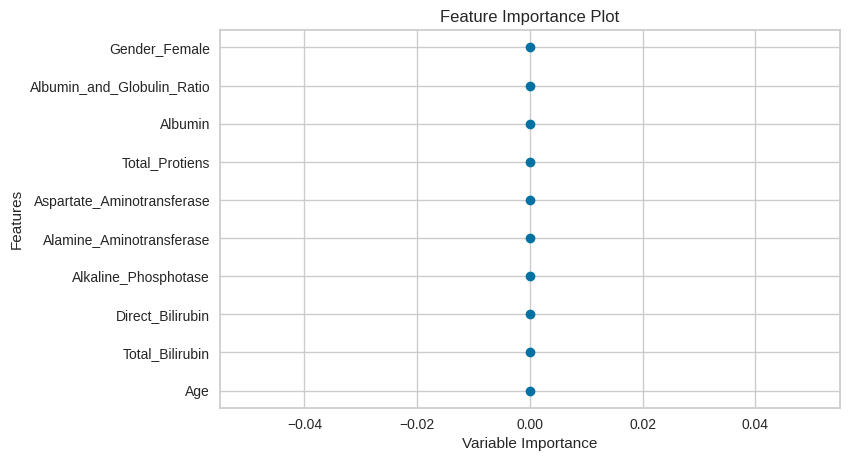

INFO:logs:Visual Rendered Successfully
INFO:logs:plot_model() succesfully completed......................................


In [38]:
# which feature is more significant
plot_model(tuned_et, plot='feature')

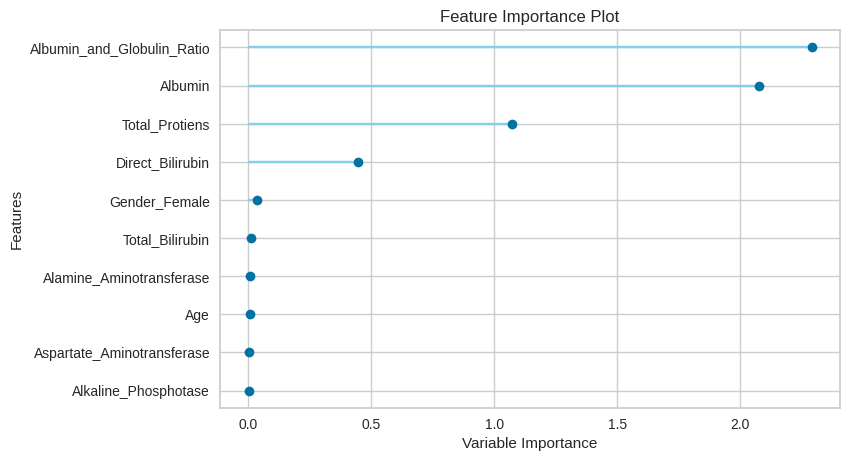

INFO:logs:Visual Rendered Successfully
INFO:logs:plot_model() succesfully completed......................................


In [39]:
plot_model(tuned_lr, plot='feature')

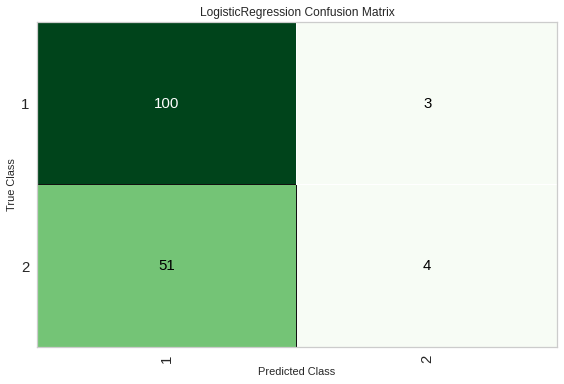

INFO:logs:Visual Rendered Successfully
INFO:logs:plot_model() succesfully completed......................................


In [40]:
plot_model(tuned_lr, plot='confusion_matrix')

In [41]:
# Evaluate the model
evaluate_model(tuned_lr)

INFO:logs:Initializing evaluate_model()
INFO:logs:evaluate_model(estimator=LogisticRegression(C=7.863, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False), fold=None, fit_kwargs=None, plot_kwargs=None, feature_name=None, groups=None, use_train_data=False)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

<Figure size 576x396 with 0 Axes>

In [42]:
# Test data - unseen data
unseen_prediction = predict_model(tuned_lr, data=data_unseen)
unseen_prediction.head()

INFO:logs:Initializing predict_model()
INFO:logs:predict_model(estimator=LogisticRegression(C=7.863, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False), probability_threshold=None, encoded_labels=False, drift_report=False, raw_score=False, round=4, verbose=True, ml_usecase=MLUsecase.CLASSIFICATION, display=None, drift_kwargs=None)
INFO:logs:Checking exceptions
INFO:logs:Preloading libraries
INFO:logs:Preparing display monitor


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7759,0.8896,1.0,0.7719,0.8713,0.1045,0.2348


IndexError: ignored

In [43]:
save_model(tuned_lr, 'tuned_lr_model')

INFO:logs:Initializing save_model()
INFO:logs:save_model(model=LogisticRegression(C=7.863, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False), model_name=tuned_lr_model, prep_pipe_=Pipeline(memory=None,
         steps=[('dtypes',
                 DataTypes_Auto_infer(categorical_features=[],
                                      display_types=True, features_todrop=[],
                                      id_columns=[],
                                      ml_usecase='classification',
                                      numerical_features=[], target='Dataset',
                                      time_features=[])),
                ('imputer',
                 Simple_Imputer(categorical_strategy='not_available',
                           

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True, features_todrop=[],
                                       id_columns=[],
                                       ml_usecase='classification',
                                       numerical_features=[], target='Dataset',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_stra...
                 ('feature_select', 'passthrough'), ('fix_multi', 'passthrough'),
                 ('dfs', 'passthrough'), ('pca', 'passthrough'),
                 ['trained_model',
                  LogisticRegression(C=7.863, class_weight={}, dual=False,
                 